# 🔮 Customer Churn Prediction Model
**Dataset:** Telco Customer Churn  
**Target:** Predict if a customer will churn (Yes/No)

## 1️⃣ Install & Import Libraries

In [1]:
# Install required libraries
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, roc_curve, ConfusionMatrixDisplay
)
import joblib

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 2️⃣ Load Data

In [11]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,is_new_customer,AvgCharges,services num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,14.925000,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,53.985714,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,36.050000,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,40.016304,2
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,50.550000,0


## 3️⃣ Exploratory Data Analysis (EDA)

In [12]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Churn Distribution ===')
print(df['Churn'].value_counts())
print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

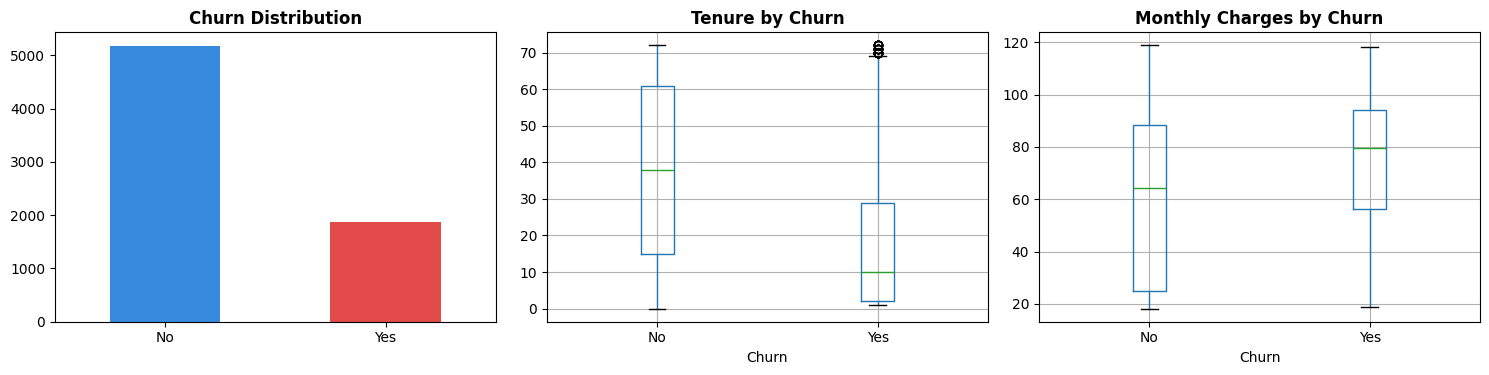

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#378ADD','#E24B4A'], edgecolor='none')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

# Tenure by churn
df.boxplot(column='tenure', by='Churn', ax=axes[1])
axes[1].set_title('Tenure by Churn', fontweight='bold')
plt.sca(axes[1])
plt.suptitle('')

# Monthly Charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges by Churn', fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

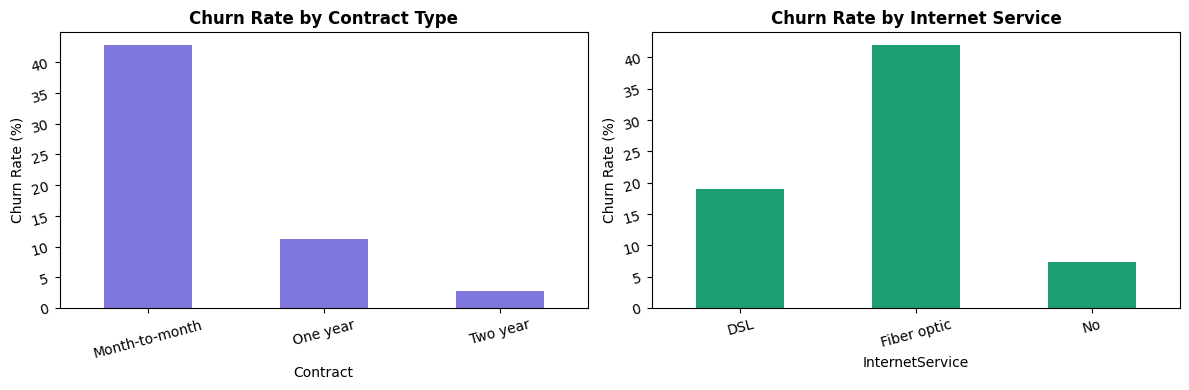

In [14]:
# Churn rate by Contract type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn.plot(kind='bar', ax=axes[0], color='#7F77DD', edgecolor='none')
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(rotation=15)

# Churn rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
internet_churn.plot(kind='bar', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(rotation=15)

plt.tight_layout()
plt.show()

## 4️⃣ Data Preprocessing

In [15]:
df_model = df.copy()

# Drop ID column
df_model = df_model.drop('customerID', axis=1)

# Encode target variable
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Encode all categorical columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f'\n✅ Features shape: {X.shape}')
print(f'Class distribution — No Churn: {(y==0).sum()}, Churn: {(y==1).sum()}')

Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Features shape: (7043, 22)
Class distribution — No Churn: 5174, Churn: 1869


In [16]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 5634 | Test size: 1409


## 5️⃣ Train Models

In [17]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f'\nTraining {name}...')

    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        y_pred  = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'auc': auc
    }

    print(f'  Accuracy: {acc:.4f} | AUC-ROC: {auc:.4f}')

print('\n✅ All models trained!')


Training Logistic Regression...
  Accuracy: 0.7424 | AUC-ROC: 0.8447

Training Random Forest...
  Accuracy: 0.7885 | AUC-ROC: 0.8176

Training Gradient Boosting...
  Accuracy: 0.8041 | AUC-ROC: 0.8428

✅ All models trained!


## 6️⃣ Evaluate Models

In [18]:
# Detailed classification report for each model
for name, res in results.items():
    print(f'\n{'='*50}')
    print(f' {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Churn', 'Churn']))


 Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


 Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


 Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg    

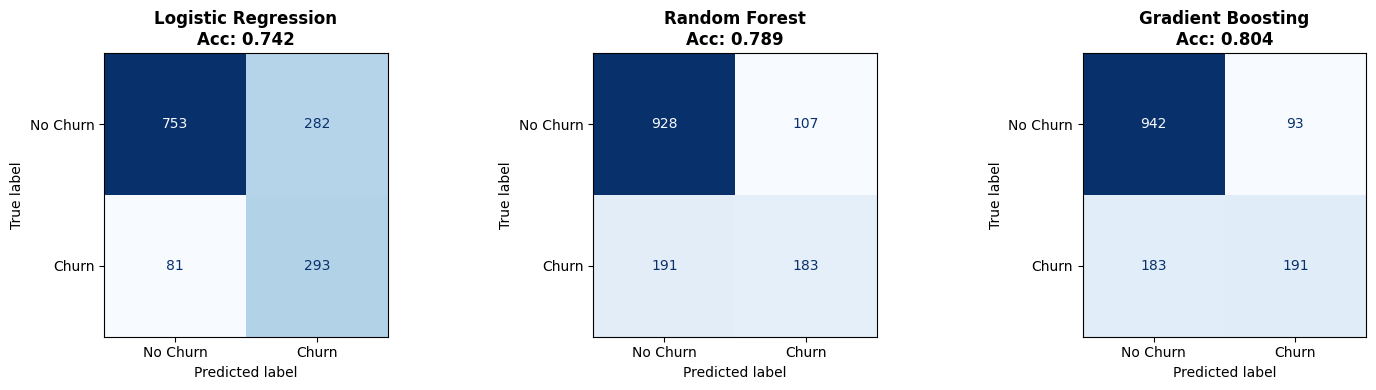

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

## 7️⃣ Feature Importance

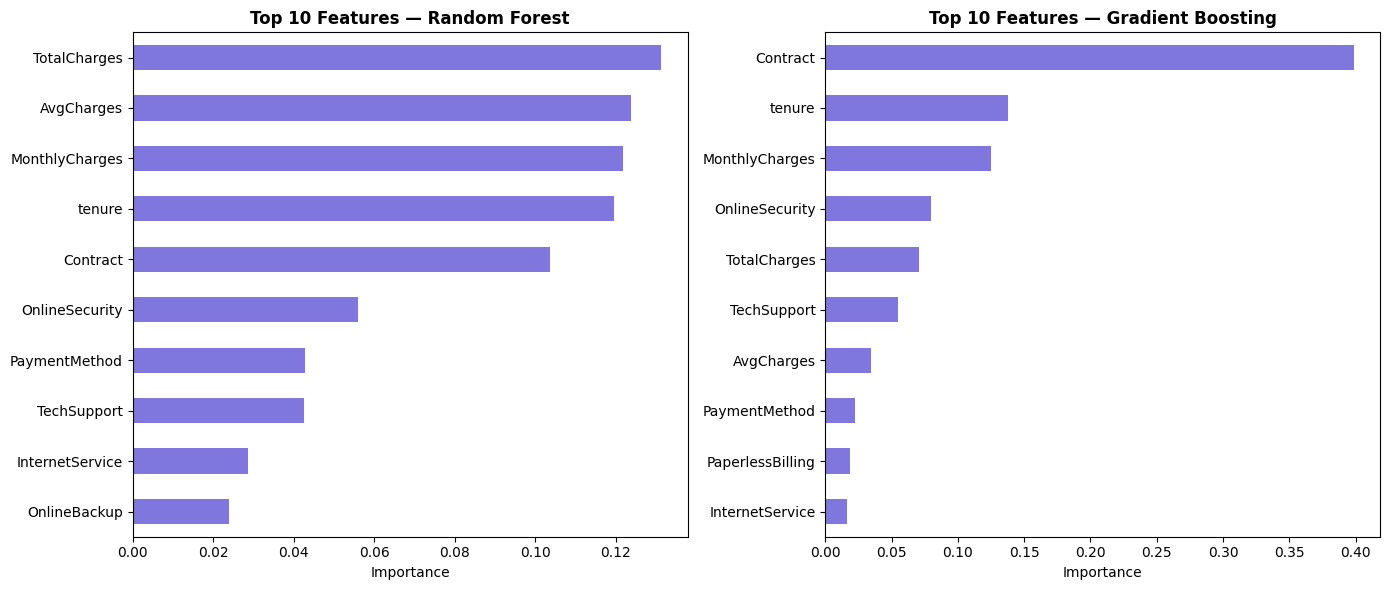

In [21]:
# Feature importance from Random Forest and Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = results[model_name]['model']
    feat_imp = pd.Series(model.feature_importances_, index=X.columns)\
                 .sort_values(ascending=True).tail(10)

    feat_imp.plot(kind='barh', ax=ax, color='#7F77DD', edgecolor='none')
    ax.set_title(f'Top 10 Features — {model_name}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 8️⃣ Hyperparameter Tuning (Best Model)

In [29]:
# Fine-tune Gradient Boosting (best model)
print('Tuning Gradient Boosting... (this may take a few minutes)')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'min_samples_split': [2, 5]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(
    gb, param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n✅ Best params: {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.4f}')

# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f'\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Test AUC-ROC: {roc_auc_score(y_test, y_proba_best):.4f}')
print('\n', classification_report(y_test, y_pred_best,
                                    target_names=['No Churn', 'Churn']))

Tuning Gradient Boosting... (this may take a few minutes)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV AUC: 0.8455

Test Accuracy: 0.8020
Test AUC-ROC: 0.8448

               precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## 9️⃣ Predict on New Customers

In [30]:
# Generate predictions for all customers and add to original dataframe
predictions = best_model.predict(X)
probabilities = best_model.predict_proba(X)[:, 1]

df_results = df.copy()
df_results['Predicted_Churn'] = ['Yes' if p == 1 else 'No' for p in predictions]
df_results['Churn_Probability'] = (probabilities * 100).round(1)
df_results['Risk_Level'] = pd.cut(
    probabilities,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

print('Sample predictions:')
df_results[['customerID', 'Churn', 'Predicted_Churn', 'Churn_Probability', 'Risk_Level']].head(10)

Sample predictions:


,customerID,Churn,Predicted_Churn,Churn_Probability,Risk_Level
0,7590-VHVEG,No,Yes,65.0,High
1,5575-GNVDE,No,No,5.2,Low
2,3668-QPYBK,Yes,No,36.5,Medium
3,7795-CFOCW,No,No,4.9,Low
4,9237-HQITU,Yes,Yes,63.6,High
5,9305-CDSKC,Yes,Yes,81.1,High
6,1452-KIOVK,No,No,46.2,Medium
7,6713-OKOMC,No,No,22.2,Low
8,7892-POOKP,Yes,Yes,55.7,Medium
9,6388-TABGU,No,No,5.2,Low


## 🔟 Save Model & Export Results

In [31]:
# Save the trained model and scaler
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('✅ Model saved as churn_model.pkl')

# Export predictions to Excel
df_results.to_excel('churn_predictions.xlsx', index=False)
print('✅ Predictions saved as churn_predictions.xlsx')

# Download files
from google.colab import files
files.download('churn_model.pkl')
files.download('churn_predictions.xlsx')

✅ Model saved as churn_model.pkl
✅ Predictions saved as churn_predictions.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>